# Multi-Object Vehicle Tracking with Ultralytics YOLO

This notebook demonstrates **multi-object tracking** using a custom-trained YOLO model (`vehicle_detection_best.pt`) that detects the following vehicle classes:

| ID | Class |
|----|-------|
| 0  | Bicycle |
| 1  | Bus |
| 2  | Car |
| 3  | Heavy truck |
| 4  | Light truck |
| 5  | Motorcycle |
| 6  | Person |
| 7  | Semi-trailer / Combination vehicle |

Tracking extends object detection by maintaining a **unique ID** for each detected object across video frames. Ultralytics YOLO supports two built-in trackers:

- **BoT-SORT** (`botsort.yaml`) — default tracker, supports ReID
- **ByteTrack** (`bytetrack.yaml`) — fast, lightweight tracker

> 📖 Reference: [Ultralytics Track Docs](https://docs.ultralytics.com/modes/track/)

## Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
%pip install -U ultralytics 

In [9]:
#%pip install ultralytics opencv-python-headless --quiet

import torch
import os
from ultralytics import YOLO
import cv2
from collections import defaultdict
import numpy as np
from datetime import datetime
import time


if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found — running on CPU")


GPU available: Tesla T4
VRAM: 15.6 GB


## GitHub — Klon eller oppdater repo

## 1. Setup — Load Model and Configure Video Source

## 1. Setup — Load Model and Configure Video Source

In [66]:
Model = "yolo26_fine-tuned.pt"
#Model = "YOLO26s.pt"
#Model = "vehicle_detection_best.pt"
YAML = "my_new_botsort.yaml"
#VIDEO = "Kjorbekk_3000965_03.mp4"
#VIDEO = "kamera_1429012_20260310_1058_02.mp4"
VIDEO = "Fv587_Haukeland_1.mp4"


try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DRIVE_BASE   = "/content/drive/MyDrive/SVV/Master_Thesis/Model"

if IN_COLAB:
    RUNS_DIR       = f"{DRIVE_BASE}/runs"
    MODEL_PATH     = f"{DRIVE_BASE}/{Model}"
    CUSTOM_TRACKER = f"{DRIVE_BASE}/{YAML}"
    VIDEO_SOURCE   = f"{DRIVE_BASE}/Video/{VIDEO}"
else:
    _notebook_dir  = os.path.dirname(os.path.abspath("tracking.ipynb"))
    RUNS_DIR       = os.path.normpath(os.path.join(_notebook_dir, "..", "runs"))
    MODEL_PATH     = os.path.join(_notebook_dir, f"{Model}")
    CUSTOM_TRACKER = os.path.join(_notebook_dir, f"{YAML}")
    VIDEO_SOURCE   = os.path.join(_notebook_dir, "Video", f"{VIDEO}")

os.makedirs(RUNS_DIR, exist_ok=True)

model = YOLO(MODEL_PATH)

class_names = model.names
print(f"Environment    : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Model          : {MODEL_PATH}")
print(f"Custom tracker : {CUSTOM_TRACKER}")
print(f"Video source   : {VIDEO_SOURCE}")
print(f"Runs dir       : {RUNS_DIR}")
print(f"Classes        : {class_names}")

# Test video-tilgang
cap = cv2.VideoCapture(VIDEO_SOURCE)
if not cap.isOpened():
    print(f"Kunne ikke åpne video: {VIDEO_SOURCE}")
else:
    print(f"Video åpnet: {VIDEO_SOURCE}")
    ret, frame = cap.read()

Environment    : Google Colab
Model          : /content/drive/MyDrive/SVV/Master_Thesis/Model/yolo26_fine-tuned.pt
Custom tracker : /content/drive/MyDrive/SVV/Master_Thesis/Model/my_new_botsort.yaml
Video source   : /content/drive/MyDrive/SVV/Master_Thesis/Model/Video/Fv587_Haukeland_1.mp4
Runs dir       : /content/drive/MyDrive/SVV/Master_Thesis/Model/runs
Classes        : {0: 'bicycle', 1: 'bus', 2: 'car', 3: 'heavy truck', 4: 'light truck', 5: 'motorcycle', 6: 'person', 7: 'semi-trailer / combination vehicle'}
Video åpnet: /content/drive/MyDrive/SVV/Master_Thesis/Model/Video/Fv587_Haukeland_1.mp4


In [58]:
#print hva som er i my_botsort.yaml
with open(CUSTOM_TRACKER, "r") as f:
    print(f"\nInnhold i {CUSTOM_TRACKER}:\n")
    print(f.read())


Innhold i /content/drive/MyDrive/SVV/Master_Thesis/Model/my_new_botsort.yaml:

tracker_type: botsort # (str) Tracker backend: botsort|bytetrack; choose botsort to enable BoT-SORT features
track_high_thresh: 0.25 # (float) First-stage match threshold; raise for cleaner tracks, lower to keep more
track_low_thresh: 0.1 # (float) Second-stage threshold for low-score matches; balances recovery vs drift
new_track_thresh: 0.25 # (float) Start a new track if no match ≥ this; higher reduces false tracks
track_buffer: 30 # (int) Frames to keep lost tracks alive; higher handles occlusion, increases ID switches risk
match_thresh: 0.8 # (float) Association similarity threshold (IoU/cost); tune with detector quality
fuse_score: True # (bool) Fuse detection score with motion/IoU for matching; stabilizes weak detections

# BoT-SORT specifics
gmc_method: none # (str) Global motion compensation: sparseOptFlow|orb|sift|ecc|none; helps moving camera scenes

# ReID model related thresh
proximity_thresh: 0

## 2. Tracking model BOTsort/Bytetrack

In [23]:
def run_tracking_instance(
    model,
    video_source,
    runs_dir,
    custom_tracker,
    track_display_len: int = 150,
    conf_thres: float = 0.6,
    iou_thres: float = 0.4,
    inner_ratio_w: float = 0.90,
    inner_ratio_h: float = 0.90,
    min_track_frames: int = 1,
) -> dict:
    """
    Kjører tracking på en videofil med BoT-SORT (eller annet Ultralytics-trackeroppsett),
    lagrer annotert video og skriver ut stats til terminalen.

    Returnerer dict med mp4_path, elapsed_time, og unique_ids.
    NB: ID-ene i loggen er de samme rå track-ID-ene som i videoen,
    men vi filtrerer bort svært korte tracks (< min_track_frames).
    """

    # Historikk per RÅ track-ID (samme som i video-labels)
    track_history = defaultdict(list)
    class_conf_history = defaultdict(lambda: defaultdict(list))
    track_frame_count = defaultdict(int)

    # For diagnostikk
    frames_with_dets_no_ids = 0
    total_raw_detections = 0

    # Video source
    cap = cv2.VideoCapture(video_source)
    if not cap.isOpened():
        raise RuntimeError(f"Kunne ikke åpne video: {video_source}")

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps < 0.1:
        print("⚠️ Lav source FPS oppdaget (< 5). Bruker lav conf, full ROI og høy imgsz.")
        conf_thres = min(conf_thres, 0.05)
        inner_ratio_w = 1.00
        inner_ratio_h = 1.00

    # Output paths
    timestamp = datetime.now().strftime("%H%M%S")
    source_stem = os.path.splitext(os.path.basename(video_source))[0]
    out_dir = os.path.join(runs_dir, "instance")
    os.makedirs(out_dir, exist_ok=True)
    avi_path = os.path.join(out_dir, f"{source_stem}_{timestamp}.avi")
    mp4_path = avi_path.replace(".avi", ".mp4")

    out = cv2.VideoWriter(avi_path, cv2.VideoWriter_fourcc(*"MJPG"), fps, (w, h))
    raw_ids_seen = set()
    frame_count = 0
    t0 = time.time()

    x_margin = int((1 - inner_ratio_w) * w / 2)
    y_margin = int((1 - inner_ratio_h) * h / 2)
    x0, x1 = x_margin, w - x_margin
    y0, y1 = y_margin, h - y_margin

    # Hovedløkken
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1

        # Kjør tracking kun på ROI
        roi = frame[y0:y1, x0:x1]
        results = model.track(
            roi,
            persist=True,
            conf=conf_thres,
            iou=iou_thres,
            tracker=custom_tracker,
            verbose=False,
        )

        # Plot på ROI og legg tilbake i full frame
        # (bruker Ultralytics sine standard labels = rå track-ID)
        annotated = frame.copy()
        annotated_roi = results[0].plot(color_mode="instance", line_width=2)
        annotated[y0:y1, x0:x1] = annotated_roi

        # (valgfritt) vis ROI-boks
        
        cv2.rectangle(annotated, (x0, y0), (x1, y1), (0, 255, 255), 2)

        has_boxes = (
            results[0].boxes is not None
            and results[0].boxes.xywh is not None
            and len(results[0].boxes) > 0
        )

        if has_boxes:
            total_raw_detections += len(results[0].boxes)

        if has_boxes and results[0].boxes.id is None:
            frames_with_dets_no_ids += 1

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            class_ids = (
                results[0].boxes.cls.int().cpu().tolist()
                if results[0].boxes.cls is not None
                else [0] * len(track_ids)
            )
            confs = (
                results[0].boxes.conf.cpu().tolist()
                if results[0].boxes.conf is not None
                else [1.0] * len(track_ids)
            )

            for box, tid, clsid, conf in zip(boxes, track_ids, class_ids, confs):
                tid = int(tid)
                clsid = int(clsid)

                raw_ids_seen.add(tid)
                track_frame_count[tid] += 1
                class_conf_history[tid][clsid].append(float(conf))

                # Trail i full frame
                cx = float(box[0]) + x0
                cy = float(box[1]) + y0
                track = track_history[tid]
                track.append((cx, cy))
                if len(track) > track_display_len:
                    track.pop(0)

                if len(track) > 1:
                    pts = np.array(track, dtype=np.int32).reshape((-1, 1, 2))
                    cv2.polylines(annotated, [pts], isClosed=False, color=(0, 200, 255), thickness=2)

        out.write(annotated)

        if frame_count % 100 == 0:
            elapsed = max(time.time() - t0, 1e-6)
            print(
                f"  {frame_count}/{total_frames} frames  |  {frame_count/elapsed:.1f} FPS",
                end="\r",
            )

    cap.release()
    out.release()

    # Konverter til mp4
    elapsed = max(time.time() - t0, 1e-6)
    os.system(
        f'ffmpeg -y -i "{avi_path}" -vcodec libx264 -crf 23 "{mp4_path}" -loglevel quiet'
    )
    os.remove(avi_path)

    stable_ids = [tid for tid in sorted(raw_ids_seen) if track_frame_count[tid] >= min_track_frames]
    short_ids = [tid for tid in sorted(raw_ids_seen) if track_frame_count[tid] < min_track_frames]

    # Logging
    print(f"\n✅ Lagret til: {mp4_path}")
    print(f"Tracker: {custom_tracker}")
    print(
        f"Tid: {elapsed:.1f}s  |  FPS: {frame_count/elapsed:.1f}  |  "
        f"Unike stabile track-IDer (>= {min_track_frames} frames): {len(stable_ids)}"
    )
    print(
        f"Rå deteksjoner totalt: {total_raw_detections}  |  "
        f"Frames med deteksjon men uten track-ID: {frames_with_dets_no_ids}"
    )

    print(f"\nKlasser per unik track-ID (filtrert, >= {min_track_frames} frames):")
    for tid in stable_ids:
        class_stats = {
            cid: {
                "frames": len(cvals),
                "mean_conf": float(np.mean(cvals)),
            }
            for cid, cvals in class_conf_history[tid].items()
            if len(cvals) > 0
        }
        if not class_stats:
            continue

        final_cls = max(
            class_stats,
            key=lambda cid: (class_stats[cid]["frames"], class_stats[cid]["mean_conf"]),
        )

        all_classes = ", ".join(
            f"{model.names[cid]}[{class_stats[cid]['frames']} f, {class_stats[cid]['mean_conf']:.3f}]"
            for cid in sorted(class_stats)
            if cid in model.names
        )
        print(
            f"  ID {tid:>4}: {model.names[final_cls]} "
            f"({class_stats[final_cls]['frames']} frames, mean conf: {class_stats[final_cls]['mean_conf']:.3f})"
            f"  |  alle klasser: {all_classes}"
        )

    print("\nStabile track-IDer:", stable_ids)
    if short_ids:
        print(f"Korte tracks filtrert bort (< {min_track_frames} frames):", short_ids)

    return {
        "mp4_path": mp4_path,
        "elapsed_time": elapsed,
        "unique_ids": len(stable_ids),
        "track_ids": stable_ids,
        "all_track_ids": sorted(raw_ids_seen),
        "filtered_out_ids": short_ids,
        "min_track_frames": min_track_frames,
        "raw_detections": total_raw_detections,
        "frames_with_dets_no_ids": frames_with_dets_no_ids,
    }

In [24]:
results_botsort = run_tracking_instance(
    model=model,
    video_source=VIDEO_SOURCE,
    runs_dir=RUNS_DIR,
    custom_tracker=CUSTOM_TRACKER,
    conf_thres=0.6,
    iou_thres=0.5,
    inner_ratio_w=0.8,
    inner_ratio_h=0.8,
    min_track_frames=5,
)
# Vis resultat
from IPython.display import Video, display
display(Video(results_botsort['mp4_path'], embed=True, width=900))
print(results_botsort)

  600/600 frames  |  49.9 FPS
✅ Lagret til: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_1_095933.mp4
Tracker: /content/drive/MyDrive/SVV/Master_Thesis/Model/my_new_botsort.yaml
Tid: 12.0s  |  FPS: 49.9  |  Unike stabile track-IDer (>= 5 frames): 12
Rå deteksjoner totalt: 1923  |  Frames med deteksjon men uten track-ID: 1

Klasser per unik track-ID (filtrert, >= 5 frames):
  ID  116: car (89 frames, mean conf: 0.818)  |  alle klasser: car[89 f, 0.818]
  ID  117: car (92 frames, mean conf: 0.914)  |  alle klasser: car[92 f, 0.914]
  ID  118: car (140 frames, mean conf: 0.863)  |  alle klasser: car[140 f, 0.863]
  ID  119: car (164 frames, mean conf: 0.894)  |  alle klasser: car[164 f, 0.894]
  ID  120: car (341 frames, mean conf: 0.882)  |  alle klasser: car[341 f, 0.882]
  ID  122: car (211 frames, mean conf: 0.884)  |  alle klasser: car[211 f, 0.884]
  ID  124: car (78 frames, mean conf: 0.790)  |  alle klasser: car[78 f, 0.790], heavy truck[3 f, 0.840]

{'mp4_path': '/content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_1_095933.mp4', 'elapsed_time': 12.026962280273438, 'unique_ids': 12, 'track_ids': [116, 117, 118, 119, 120, 122, 124, 126, 127, 128, 130, 131], 'all_track_ids': [116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131], 'filtered_out_ids': [121, 123, 125, 129], 'min_track_frames': 5, 'raw_detections': 1923, 'frames_with_dets_no_ids': 1}


In [68]:
results_bytetrack = run_tracking_instance(
    model=model,
    video_source=VIDEO_SOURCE,
    runs_dir=RUNS_DIR,
    custom_tracker="bytetrack.yaml",
    conf_thres=0.6,
    iou_thres=0.5,
    inner_ratio_w=0.8,
    inner_ratio_h=0.8,
    min_track_frames=5,  # Færre frames før ID regnes som valid
)
# Vis resultat
from IPython.display import Video, display
display(Video(results_bytetrack['mp4_path'], embed=True, width=900))
print(results_bytetrack)


  600/600 frames  |  46.5 FPS
✅ Lagret til: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_1_140344.mp4
Tracker: bytetrack.yaml
Tid: 12.9s  |  FPS: 46.4  |  Unike stabile track-IDer (>= 5 frames): 12
Rå deteksjoner totalt: 1923  |  Frames med deteksjon men uten track-ID: 1

Klasser per unik track-ID (filtrert, >= 5 frames):
  ID   17: car (89 frames, mean conf: 0.818)  |  alle klasser: car[89 f, 0.818]
  ID   18: car (92 frames, mean conf: 0.914)  |  alle klasser: car[92 f, 0.914]
  ID   19: car (140 frames, mean conf: 0.863)  |  alle klasser: car[140 f, 0.863]
  ID   20: car (164 frames, mean conf: 0.894)  |  alle klasser: car[164 f, 0.894]
  ID   21: car (341 frames, mean conf: 0.882)  |  alle klasser: car[341 f, 0.882]
  ID   23: car (211 frames, mean conf: 0.884)  |  alle klasser: car[211 f, 0.884]
  ID   25: car (78 frames, mean conf: 0.790)  |  alle klasser: car[78 f, 0.790], heavy truck[3 f, 0.840], light truck[14 f, 0.726]
  ID   27: car (162 frame

{'mp4_path': '/content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_1_140344.mp4', 'elapsed_time': 12.919838428497314, 'unique_ids': 12, 'track_ids': [17, 18, 19, 20, 21, 23, 25, 27, 28, 29, 31, 32], 'all_track_ids': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], 'filtered_out_ids': [22, 24, 26, 30], 'min_track_frames': 5, 'raw_detections': 1923, 'frames_with_dets_no_ids': 1}


## LIVE

In [ ]:
import cv2
import time
import base64
from IPython.display import display, HTML, clear_output

In [ ]:
from collections import deque as _deque

def run_tracking_live_notebook(
    model,
    video_source,
    custom_tracker,
    conf_thres=0.3,
    iou_thres=0.4,
    inner_ratio_w=0.9,
    inner_ratio_h=0.6,
    track_display_len=120,
    min_track_frames=10,
    status_every=100,
    show_roi_box=True,
    display_delay_seconds=10,
):
    """
    Kjører live tracking i notebook.
    display_delay_seconds: antall sekunder forsinkelse før frames vises (0 = ingen forsinkelse).
    """

    cap = cv2.VideoCapture(video_source)

    if not cap.isOpened():
        print("Kunne ikke åpne stream.")
        return

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    x_margin = int((1 - inner_ratio_w) * w / 2)
    y_margin = int((1 - inner_ratio_h) * h / 2)

    x0, x1 = x_margin, w - x_margin
    y0, y1 = y_margin, h - y_margin

    frame_count = 0
    t0 = time.time()

    track_history = defaultdict(list)
    track_frame_count = defaultdict(int)
    raw_ids_seen = set()

    # Buffer for forsinkelse: (capture_timestamp, annotated_frame)
    frame_buffer = _deque()

    display_handle = display(HTML("<img id='live'>"), display_id=True)

    if display_delay_seconds > 0:
        print(f"Venter {display_delay_seconds}s før visning starter (buffrer frames)...")

    while True:

        ret, frame = cap.read()
        if not ret:
            print("Stream stoppet.")
            break

        frame_count += 1
        capture_time = time.time()

        roi = frame[y0:y1, x0:x1]

        results = model.track(
            roi,
            persist=True,
            conf=conf_thres,
            iou=iou_thres,
            tracker=custom_tracker,
            verbose=False
        )

        annotated = frame.copy()
        annotated_roi = results[0].plot(color_mode="instance", line_width=2)
        annotated[y0:y1, x0:x1] = annotated_roi

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, tid in zip(boxes, track_ids):
                tid = int(tid)
                raw_ids_seen.add(tid)
                track_frame_count[tid] += 1

                cx = float(box[0]) + x0
                cy = float(box[1]) + y0

                track = track_history[tid]
                track.append((cx, cy))
                if len(track) > track_display_len:
                    track.pop(0)

                if len(track) > 1:
                    pts = np.array(track, dtype=np.int32).reshape((-1, 1, 2))
                    cv2.polylines(
                        annotated,
                        [pts],
                        isClosed=False,
                        color=(0, 200, 255),
                        thickness=2,
                    )

        if show_roi_box:
            cv2.rectangle(annotated, (x0, y0), (x1, y1), (0, 255, 255), 2)

        # Legg annotert frame i buffer med tidsstempel
        frame_buffer.append((capture_time, annotated))

        # Vis frame kun hvis det er gammelt nok
        now = time.time()
        if frame_buffer and (now - frame_buffer[0][0]) >= display_delay_seconds:
            _, display_frame = frame_buffer.popleft()
            _, buffer = cv2.imencode('.jpg', display_frame)
            jpg_as_text = base64.b64encode(buffer).decode()
            display_handle.update(
                HTML(f"<img src='data:image/jpeg;base64,{jpg_as_text}' width=900>")
            )

        if frame_count % status_every == 0:
            elapsed = max(time.time() - t0, 1e-6)
            fps_live = frame_count / elapsed
            stable_ids = [
                tid for tid in sorted(raw_ids_seen)
                if track_frame_count[tid] >= min_track_frames
            ]
            short_ids = [
                tid for tid in sorted(raw_ids_seen)
                if track_frame_count[tid] < min_track_frames
            ]
            print(
                f"Frame {frame_count} | FPS: {fps_live:.1f} | "
                f"Buffer: {len(frame_buffer)} frames | "
                f"Stabile ID-er (>= {min_track_frames}): {len(stable_ids)} | "
                f"Korte ID-er: {len(short_ids)}"
            )

    cap.release()
    elapsed = max(time.time() - t0, 1e-6)
    stable_ids = [
        tid for tid in sorted(raw_ids_seen)
        if track_frame_count[tid] >= min_track_frames
    ]
    short_ids = [
        tid for tid in sorted(raw_ids_seen)
        if track_frame_count[tid] < min_track_frames
    ]

    print(
        f"\nFerdig live tracking | Tid: {elapsed:.1f}s | "
        f"Gj.snitt FPS: {frame_count/elapsed:.1f}"
    )
    print(f"Stabile ID-er (>= {min_track_frames}): {stable_ids}")
    if short_ids:
        print(f"Korte ID-er filtrert bort: {short_ids}")

    return {
        "elapsed_time": elapsed,
        "frames": frame_count,
        "stable_track_ids": stable_ids,
        "all_track_ids": sorted(raw_ids_seen),
        "filtered_out_ids": short_ids,
        "min_track_frames": min_track_frames,
    }


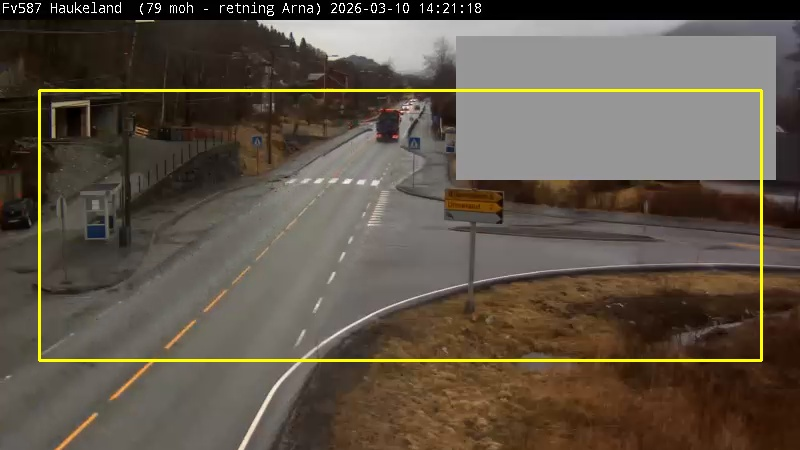

Venter 10s før visning starter (buffrer frames)...
Frame 100 | FPS: 32.0 | Buffer: 100 frames | Stabile ID-er (>= 10): 1 | Korte ID-er: 1
Frame 200 | FPS: 37.3 | Buffer: 200 frames | Stabile ID-er (>= 10): 4 | Korte ID-er: 1
Frame 300 | FPS: 40.2 | Buffer: 300 frames | Stabile ID-er (>= 10): 8 | Korte ID-er: 3
Frame 400 | FPS: 26.9 | Buffer: 317 frames | Stabile ID-er (>= 10): 15 | Korte ID-er: 1
Frame 500 | FPS: 20.5 | Buffer: 317 frames | Stabile ID-er (>= 10): 19 | Korte ID-er: 1


KeyboardInterrupt: 

In [ ]:
VIDEO_SOURCE = "https://kamera.vegvesen.no/public/1229050_1/manifest.m3u8"

run_tracking_live_notebook(
    model=model,
    video_source=VIDEO_SOURCE,
    custom_tracker=CUSTOM_TRACKER,
    conf_thres=0.6,
    inner_ratio_w=0.90,
    inner_ratio_h=0.60,
)

## 6. Sammenligning av trackere

Tabellen under oppsummerer kjøretid og antall unike track-IDer for hvert trackingalternativ kjørt på samme video.


SAMMENLIGNING: BoT-SORT vs ByteTrack

  Tracker  Processing Time (s)  Unique IDs  Total Detections  Detections w/o ID
 BoT-SORT            13.168719          12              1923                  0
ByteTrack            12.919838          12              1923                  1

Processing FPS:
  BoT-SORT:  146.0 FPS
  ByteTrack: 148.8 FPS


SAMMENLIGNING: BoT-SORT vs ByteTrack

  Tracker  Processing Time (s)  Unique IDs  Total Detections  Detections w/o ID
 BoT-SORT            13.168719          12              1923                  0
ByteTrack            12.919838          12              1923                  1

Processing FPS:
  BoT-SORT:  146.0 FPS
  ByteTrack: 148.8 FPS


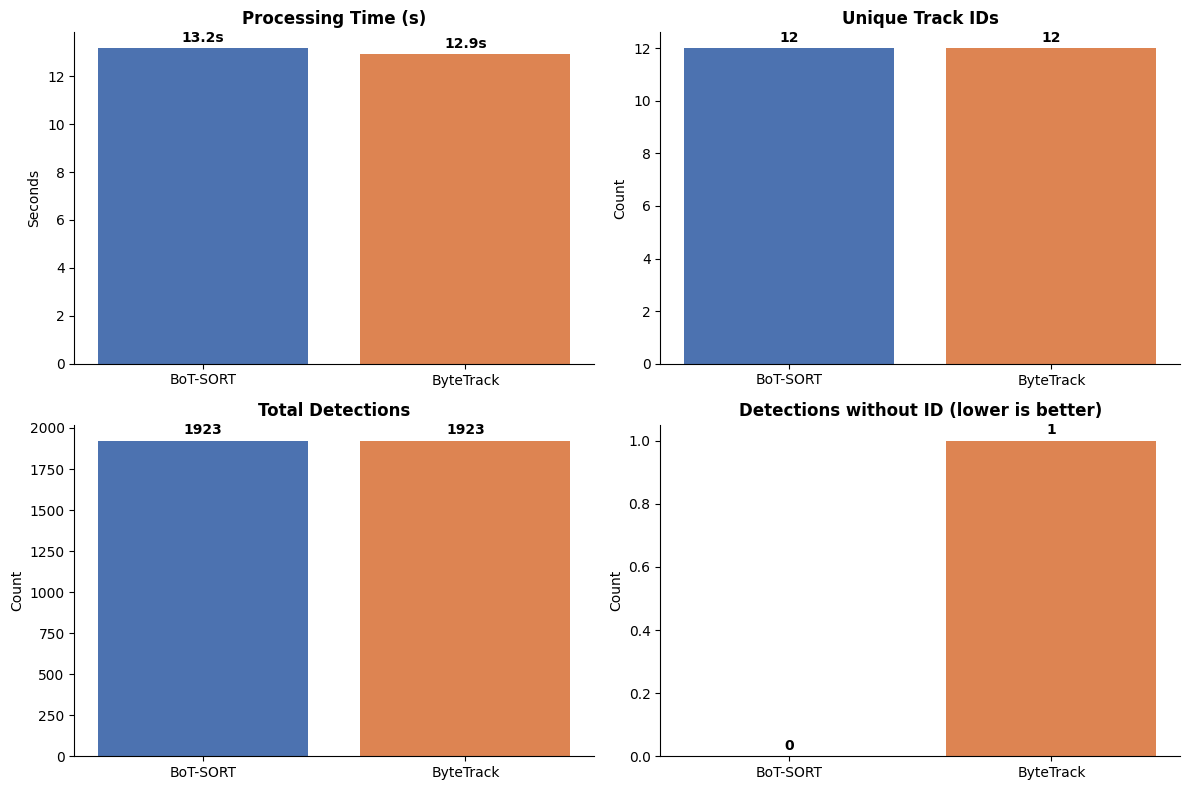


✅ Sammenligning ferdig!


In [70]:
# Sammenligning av BoT-SORT vs ByteTrack
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("SAMMENLIGNING: BoT-SORT vs ByteTrack")
print("=" * 80)

# Hent data fra begge kjøringer
botsort_data = {
    "Tracker": "BoT-SORT",
    "Processing Time (s)": results_botsort['elapsed_time'],
    "Unique IDs": results_botsort['unique_ids'],
    "Total Detections": results_botsort['raw_detections'],
    "Detections w/o ID": results_botsort['frames_with_dets_no_ids'],
}

bytetrack_data = {
    "Tracker": "ByteTrack",
    "Processing Time (s)": results_bytetrack['elapsed_time'],
    "Unique IDs": results_bytetrack['unique_ids'],
    "Total Detections": results_bytetrack['raw_detections'],
    "Detections w/o ID": results_bytetrack['frames_with_dets_no_ids'],
}

# Lag DataFrame
comparison_df = pd.DataFrame([botsort_data, bytetrack_data])
print("\n" + comparison_df.to_string(index=False))

# Beregn prosessering FPS
if results_botsort['elapsed_time'] > 0:
    botsort_fps = results_botsort['raw_detections'] / results_botsort['elapsed_time']
else:
    botsort_fps = 0
    
if results_bytetrack['elapsed_time'] > 0:
    bytetrack_fps = results_bytetrack['raw_detections'] / results_bytetrack['elapsed_time']
else:
    bytetrack_fps = 0

print("\n" + "=" * 80)
print(f"Processing FPS:")
print(f"  BoT-SORT:  {botsort_fps:.1f} FPS")
print(f"  ByteTrack: {bytetrack_fps:.1f} FPS")
print("=" * 80)

# Visualisering
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

trackers = ["BoT-SORT", "ByteTrack"]
times = [results_botsort['elapsed_time'], results_bytetrack['elapsed_time']]
ids = [results_botsort['unique_ids'], results_bytetrack['unique_ids']]
dets = [results_botsort['raw_detections'], results_bytetrack['raw_detections']]
dets_no_id = [results_botsort['frames_with_dets_no_ids'], results_bytetrack['frames_with_dets_no_ids']]

colors = ["#4C72B0", "#DD8452"]

# Processing Time
axes[0, 0].bar(trackers, times, color=colors)
axes[0, 0].set_title("Processing Time (s)", fontweight="bold")
axes[0, 0].set_ylabel("Seconds")
for i, v in enumerate(times):
    axes[0, 0].text(i, v + max(times)*0.02, f"{v:.1f}s", ha="center", fontweight="bold")

# Unique IDs
axes[0, 1].bar(trackers, ids, color=colors)
axes[0, 1].set_title("Unique Track IDs", fontweight="bold")
axes[0, 1].set_ylabel("Count")
for i, v in enumerate(ids):
    axes[0, 1].text(i, v + max(ids)*0.02, str(v), ha="center", fontweight="bold")

# Total Detections
axes[1, 0].bar(trackers, dets, color=colors)
axes[1, 0].set_title("Total Detections", fontweight="bold")
axes[1, 0].set_ylabel("Count")
for i, v in enumerate(dets):
    axes[1, 0].text(i, v + max(dets)*0.02, str(v), ha="center", fontweight="bold")

# Detections without ID (lower is better)
axes[1, 1].bar(trackers, dets_no_id, color=colors)
axes[1, 1].set_title("Detections without ID (lower is better)", fontweight="bold")
axes[1, 1].set_ylabel("Count")
for i, v in enumerate(dets_no_id):
    axes[1, 1].text(i, v + max(dets_no_id)*0.02, str(v), ha="center", fontweight="bold")

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Sammenligning ferdig!")


## Results

## 8. Tracker Configuration Reference

### Available Trackers

| Tracker | Config file | Notes |
|---------|------------|-------|
| **BoT-SORT** | `botsort.yaml` | Default. Supports ReID for appearance-based re-identification. |
| **ByteTrack** | `bytetrack.yaml` | Fast. Uses both high- and low-confidence detections. |

### Key Tracker Arguments

| Parameter | Range | Description |
|-----------|-------|-------------|
| `track_high_thresh` | 0.0–1.0 | First-association confidence threshold. Detections below this are not used for primary matching. |
| `track_low_thresh` | 0.0–1.0 | Second-association threshold (more lenient fallback). |
| `new_track_thresh` | 0.0–1.0 | Minimum confidence to initialise a new track. |
| `track_buffer` | ≥ 0 | Frames to keep a lost track alive before deletion. Higher = more occlusion tolerance. |
| `match_thresh` | 0.0–1.0 | IoU threshold for matching detections to existing tracks. |
| `gmc_method` | orb / sift / ecc / sparseOptFlow / None | Global Motion Compensation method. Compensates for camera movement. |
| `with_reid` | True / False | Enable ReID (BoT-SORT only). Uses appearance embeddings to re-identify vehicles. |
| `proximity_thresh` | 0.0–1.0 | Minimum IoU required before ReID is applied. |
| `appearance_thresh` | 0.0–1.0 | Minimum visual similarity score for ReID matching. |

### Common `model.track()` Arguments

| Argument | Default | Description |
|----------|---------|-------------|
| `conf` | 0.25 | Detection confidence threshold. |
| `iou` | 0.7 | NMS IoU threshold. |
| `persist` | False | Set `True` when processing video frame-by-frame to maintain track IDs. |
| `tracker` | `botsort.yaml` | Tracker config file. |
| `save` | False | Save annotated output to `runs/track/`. |
| `show` | False | Display live video window. |
| `stream` | False | Return a generator (memory-efficient for long videos). |

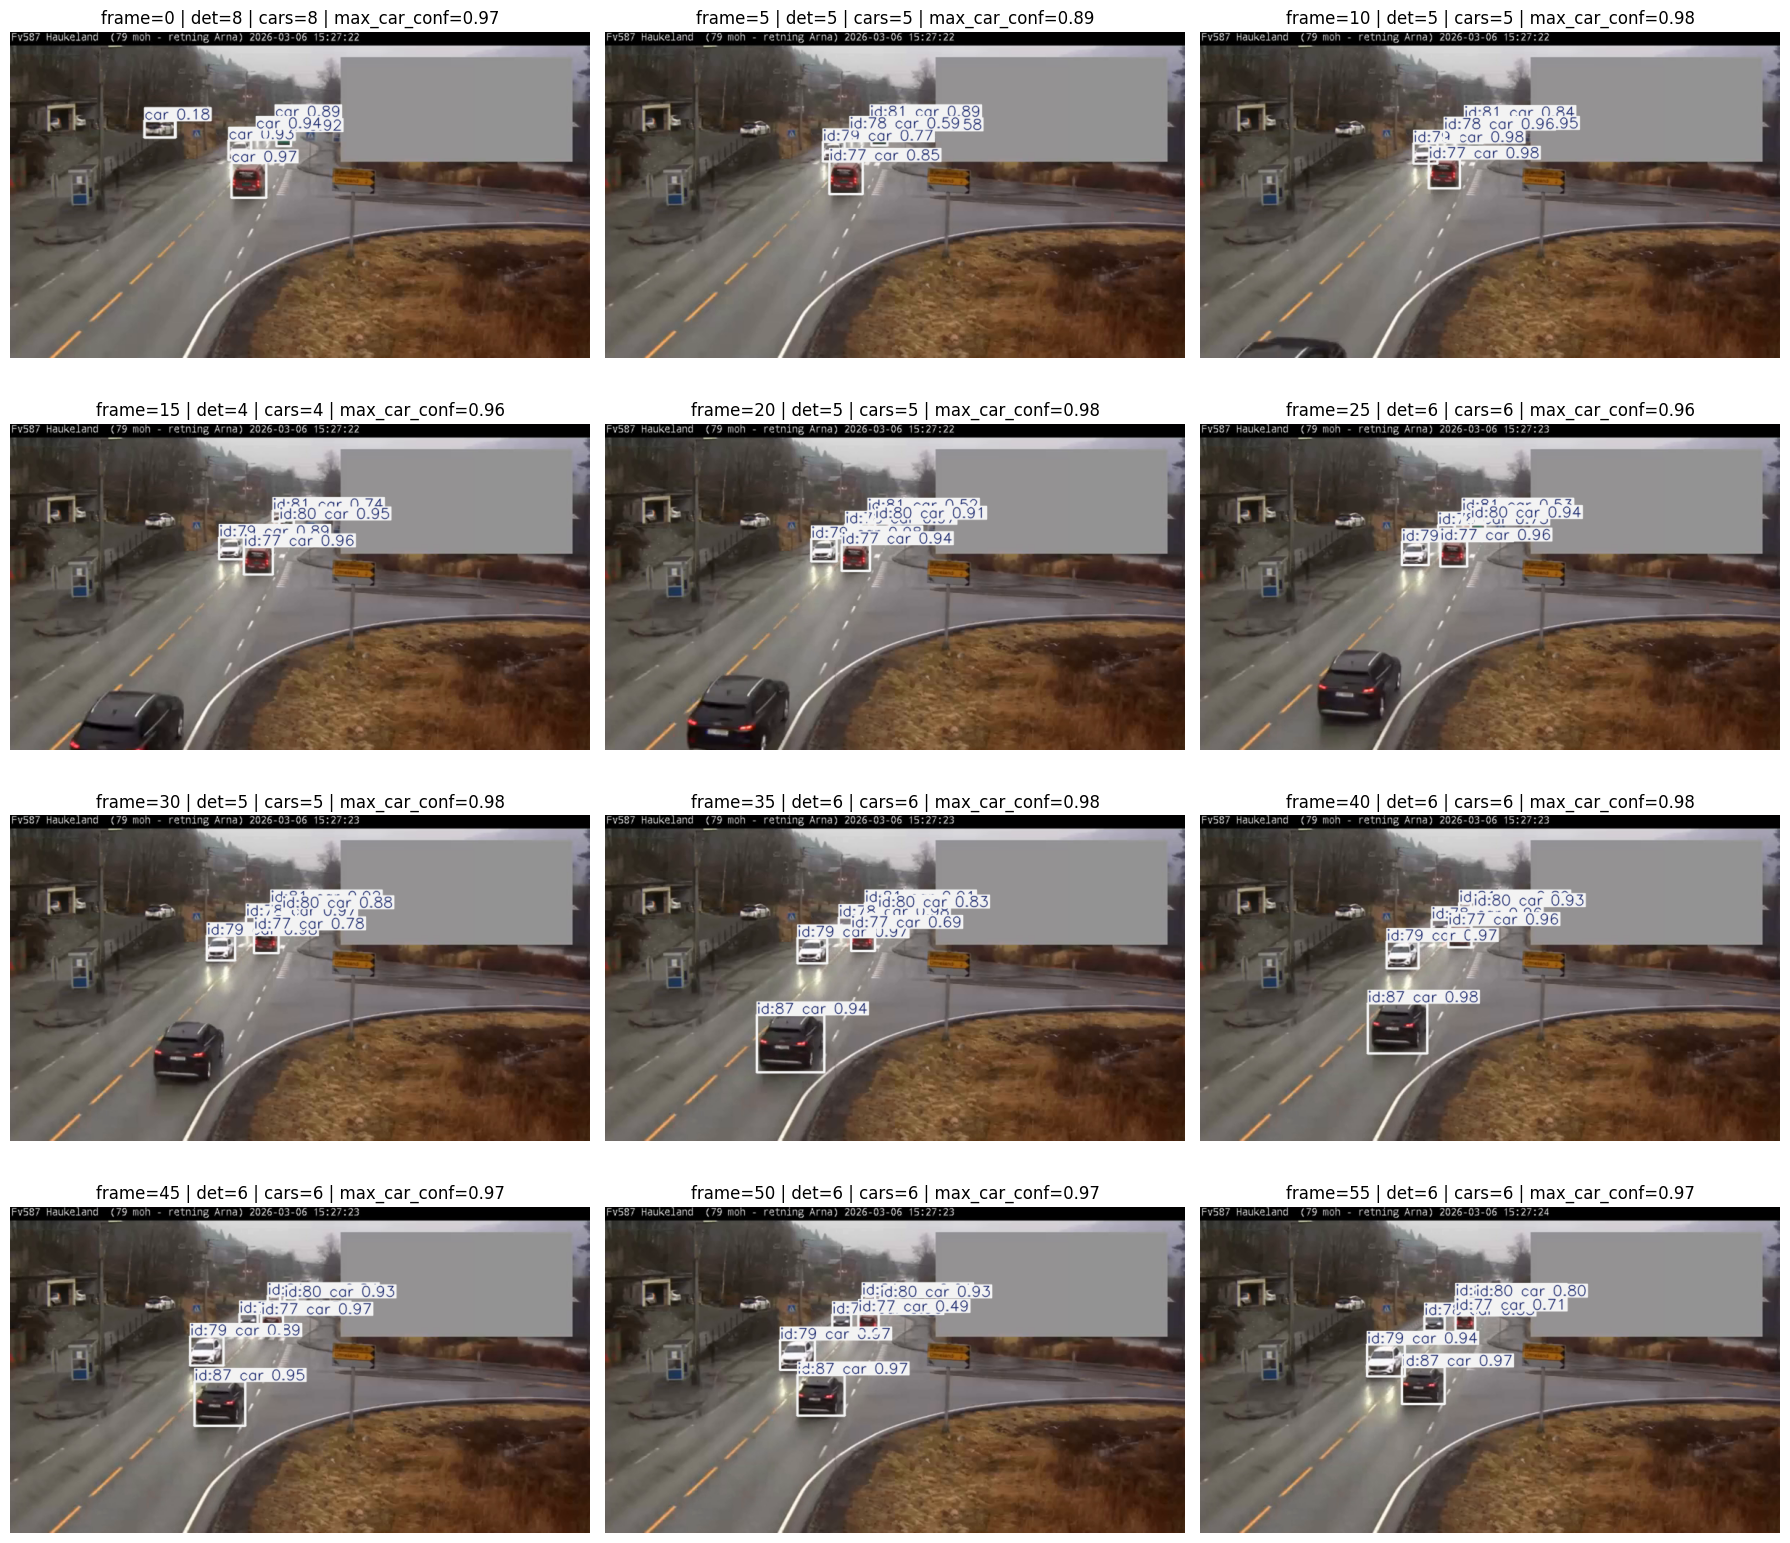

In [72]:
# Diagnostikk: sjekk om modellen faktisk detekterer biler i enkeltframes
import matplotlib.pyplot as plt

def debug_detection_samples(model, video_source, frame_step=30, max_samples=6, conf=0.05, imgsz=1280):
    cap = cv2.VideoCapture(video_source)
    if not cap.isOpened():
        print(f"Kunne ikke åpne video: {video_source}")
        return []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    samples = []
    idx = 0
    while len(samples) < max_samples and idx < total:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok:
            break

        pred = model.predict(frame, conf=conf, imgsz=imgsz, verbose=False)[0]
        n = 0 if pred.boxes is None else len(pred.boxes)
        car_count = 0
        max_car_conf = 0.0

        if pred.boxes is not None and pred.boxes.cls is not None:
            cls = pred.boxes.cls.int().cpu().tolist()
            cfs = pred.boxes.conf.cpu().tolist() if pred.boxes.conf is not None else [0.0] * len(cls)
            for c, cf in zip(cls, cfs):
                if int(c) == 2:  # car
                    car_count += 1
                    max_car_conf = max(max_car_conf, float(cf))

        samples.append((idx, n, car_count, max_car_conf, pred.plot()))
        idx += frame_step

    cap.release()

    if not samples:
        print("Ingen samples lest fra video.")
        return []

    cols = min(3, len(samples))
    rows = int(np.ceil(len(samples) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (fidx, n, ccount, cmax, img) in zip(axes, samples):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame={fidx} | det={n} | cars={ccount} | max_car_conf={cmax:.2f}")
        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return samples

samples = debug_detection_samples(
    model=model,
    video_source=VIDEO_SOURCE,
    frame_step=5,
    max_samples=12,
    conf=0.05,
    imgsz=1280,
 )